H count: 49263
original candidate rows: 51880
spatial candidate pool: 44
pair count: 61622


100%|██████████| 44/44 [00:00<00:00, 299.67it/s]

best_k: 21
     K  facility_score  covered_h_count  coverage_rate  avg_best_sim  \
20  21    36165.046306            36238       0.735603      0.734122   

    marginal_gain  coverage_gain  coverage_gain_rate  elbow_distance  
20     1046.99582         1047.0            0.021253        0.238309  
selected shape: (21, 53)
selected unique coords: 21


    selection_order  space_j_index  j_index         위도          경도  \
0                 1             29   222819  37.582331  126.983559   
1                 2             35    94626  37.630376  127.022628   
2                 3             20   163172  37.563846  126.981866   
3                 4             43    47653  37.640683  127.035490   
4                 5             39    69813  37.637817  127.038271   
5                 6             27   226277  37.578786  127.007188   
6                 7             22   158187  37.567729  127.012670   
7                 8             19   188601  37.560034  126.825876   
8                 9              8   244752  37.537680  127.085212   
9                10             26   229734  37.577740  127.008033   
10               11              9   171052  37.540264  126.993793   
11               12             33    39938  37.622024  127.077481   
12               13             18   142848  37.559675  127.131292   
13               14 

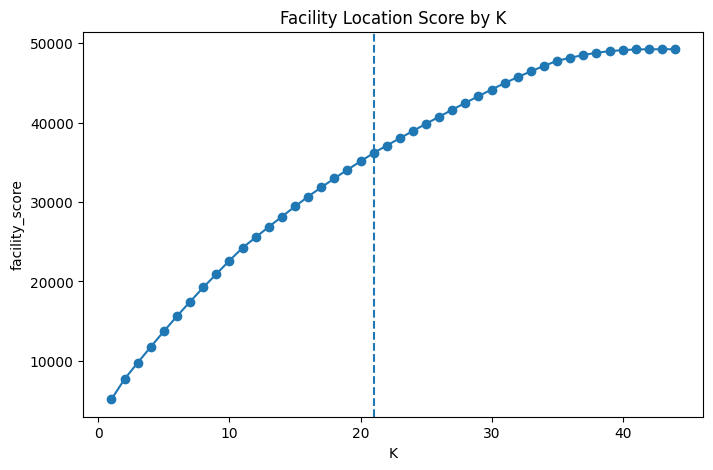

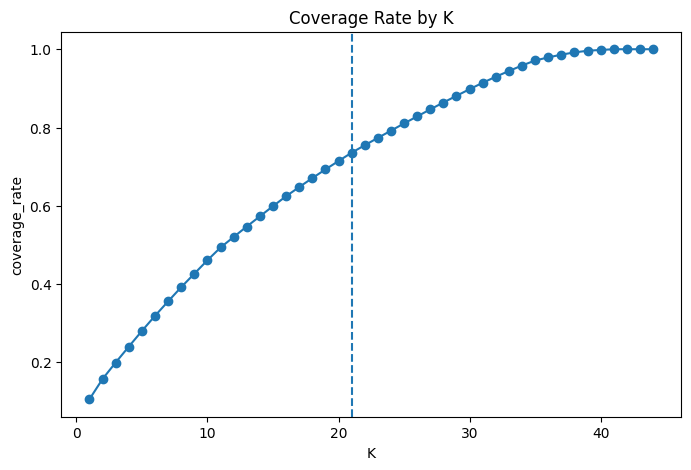

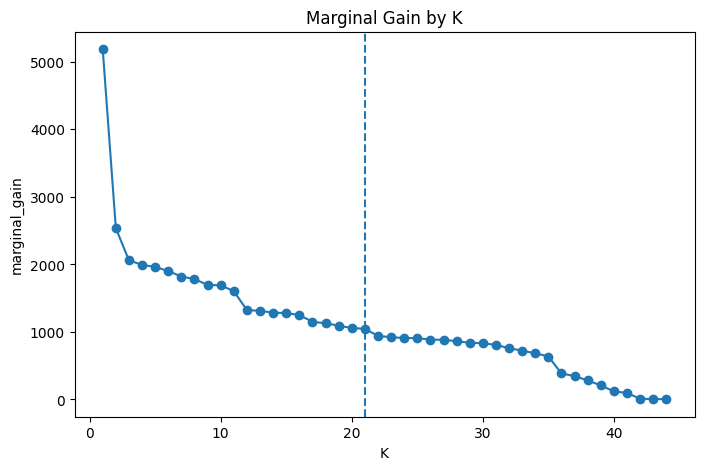

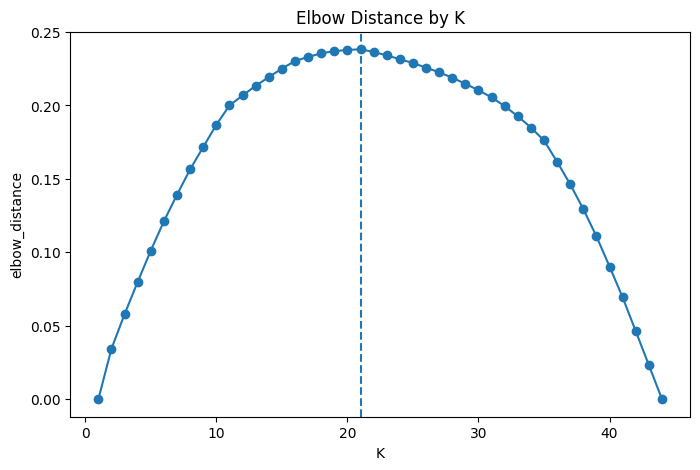

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

best_candidate_df = pd.read_csv("../DATA/PROCESS/best_candidate_df.csv")
final_candidate_local_df = pd.read_csv("../DATA/PROCESS/final_candidate_local_df.csv")

LAT_COL = "위도"
LON_COL = "경도"

final_candidate_local_df[LAT_COL] = pd.to_numeric(final_candidate_local_df[LAT_COL], errors="coerce")
final_candidate_local_df[LON_COL] = pd.to_numeric(final_candidate_local_df[LON_COL], errors="coerce")

final_candidate_local_df = final_candidate_local_df.dropna(subset=[LAT_COL, LON_COL]).copy()

final_candidate_local_df["space_key"] = (
    final_candidate_local_df[LAT_COL].round(6).astype(str)
    + "_"
    + final_candidate_local_df[LON_COL].round(6).astype(str)
)

space_candidate_df = (
    final_candidate_local_df
    .sort_values(
        ["space_key", "covered_h_count", "avg_x_sim", "avg_c_sim_scaled"],
        ascending=[True, False, False, False]
    )
    .drop_duplicates(subset=["space_key"], keep="first")
    .reset_index(drop=True)
)

space_candidate_df["space_j_index"] = np.arange(len(space_candidate_df))

j_to_space = final_candidate_local_df[["j_index", "space_key"]].merge(
    space_candidate_df[["space_key", "space_j_index"]],
    on="space_key",
    how="inner"
)

pair_df = best_candidate_df.copy()

pair_df = pair_df.merge(
    j_to_space,
    on="j_index",
    how="inner"
)

pair_df = pair_df[
    [
        "h_index",
        "space_j_index",
        "x_sim",
        "c_sim_scaled",
        "rank",
        "time_diff"
    ]
].copy()

pair_df = pair_df.sort_values(
    ["h_index", "space_j_index", "x_sim", "c_sim_scaled"],
    ascending=[True, True, False, False]
)

pair_df = pair_df.drop_duplicates(
    subset=["h_index", "space_j_index"],
    keep="first"
).reset_index(drop=True)

pair_df["sim"] = pair_df["x_sim"]

H_list = pair_df["h_index"].unique()
J_list = pair_df["space_j_index"].unique()

print("H count:", len(H_list))
print("original candidate rows:", len(final_candidate_local_df))
print("spatial candidate pool:", len(J_list))
print("pair count:", len(pair_df))

candidate_groups = {
    j: g[["h_index", "sim"]].copy()
    for j, g in pair_df.groupby("space_j_index")
}

K_max = min(100, len(J_list))

current_best = pd.Series(
    0.0,
    index=H_list
)

selected_j = []
selected_rows = []
available_j = set(candidate_groups.keys())

for step in tqdm(range(K_max)):

    best_j = None
    best_gain = -1
    best_new_score = None
    best_covered_h = None

    for j in available_j:
        g = candidate_groups[j]

        h_idx = g["h_index"].values
        sim_vals = g["sim"].values

        old_vals = current_best.loc[h_idx].values
        new_vals = np.maximum(old_vals, sim_vals)

        gain = np.sum(new_vals - old_vals)

        if gain > best_gain:
            best_gain = gain
            best_j = j
            best_new_score = new_vals
            best_covered_h = h_idx

    if best_j is None or best_gain <= 0:
        break

    current_best.loc[best_covered_h] = best_new_score

    selected_j.append(best_j)

    selected_rows.append({
        "K": step + 1,
        "selected_space_j_index": best_j,
        "marginal_gain": best_gain,
        "facility_score": current_best.sum(),
        "covered_h_count": int((current_best > 0).sum()),
        "coverage_rate": float((current_best > 0).sum() / len(H_list)),
        "avg_best_sim": float(current_best.mean())
    })

    available_j.remove(best_j)

selected_progress_df = pd.DataFrame(selected_rows)

selected_progress_df["coverage_gain"] = (
    selected_progress_df["covered_h_count"]
    .diff()
    .fillna(selected_progress_df["covered_h_count"])
)

selected_progress_df["coverage_gain_rate"] = (
    selected_progress_df["coverage_gain"] / len(H_list)
)

progress = selected_progress_df.copy()

x = progress["K"].to_numpy(dtype=float)
y = progress["facility_score"].to_numpy(dtype=float)

if len(progress) > 1 and x.max() != x.min() and y.max() != y.min():
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    elbow_distance = y_norm - x_norm
else:
    x_norm = np.zeros_like(x)
    y_norm = np.zeros_like(y)
    elbow_distance = np.zeros_like(y)

progress["x_norm"] = x_norm
progress["y_norm"] = y_norm
progress["elbow_distance"] = elbow_distance

best_k = int(
    progress.loc[
        progress["elbow_distance"].idxmax(),
        "K"
    ]
)

print("best_k:", best_k)

print(
    progress.loc[
        progress["K"] == best_k,
        [
            "K",
            "facility_score",
            "covered_h_count",
            "coverage_rate",
            "avg_best_sim",
            "marginal_gain",
            "coverage_gain",
            "coverage_gain_rate",
            "elbow_distance"
        ]
    ]
)

best_selected_space_j = selected_j[:best_k]

selected_order_df = pd.DataFrame({
    "space_j_index": best_selected_space_j,
    "selection_order": range(1, len(best_selected_space_j) + 1)
})

best_selected_j_df = space_candidate_df[
    space_candidate_df["space_j_index"].isin(best_selected_space_j)
].copy()

best_selected_j_df = best_selected_j_df.merge(
    selected_order_df,
    on="space_j_index",
    how="left"
)

best_selected_j_df = best_selected_j_df.sort_values("selection_order").reset_index(drop=True)

print("selected shape:", best_selected_j_df.shape)
print("selected unique coords:", best_selected_j_df[[LAT_COL, LON_COL]].drop_duplicates().shape[0])

print(
    best_selected_j_df[
        [
            "selection_order",
            "space_j_index",
            "j_index",
            "위도",
            "경도",
            "nearest_local_dist_m",
            "nearest_local_상권명",
            "nearest_local_자치구",
            "covered_h_count",
            "avg_x_sim",
            "avg_c_sim_scaled",
            "avg_rank",
            "avg_time_diff"
        ]
    ].head(best_k)
)

plt.figure(figsize=(8, 5))
plt.plot(progress["K"], progress["facility_score"], marker="o")
plt.axvline(best_k, linestyle="--")
plt.title("Facility Location Score by K")
plt.xlabel("K")
plt.ylabel("facility_score")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(progress["K"], progress["coverage_rate"], marker="o")
plt.axvline(best_k, linestyle="--")
plt.title("Coverage Rate by K")
plt.xlabel("K")
plt.ylabel("coverage_rate")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(progress["K"], progress["marginal_gain"], marker="o")
plt.axvline(best_k, linestyle="--")
plt.title("Marginal Gain by K")
plt.xlabel("K")
plt.ylabel("marginal_gain")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(progress["K"], progress["elbow_distance"], marker="o")
plt.axvline(best_k, linestyle="--")
plt.title("Elbow Distance by K")
plt.xlabel("K")
plt.ylabel("elbow_distance")
plt.show()

best_selected_j_df.to_csv(
    "../DATA/PROCESS/facility_location_best_selected_j.csv",
    index=False,
    encoding="utf-8-sig"
)

progress.to_csv(
    "../DATA/PROCESS/facility_location_k_experiment.csv",
    index=False,
    encoding="utf-8-sig"
)

space_candidate_df.to_csv(
    "../DATA/PROCESS/final_candidate_local_spatial_df.csv",
    index=False,
    encoding="utf-8-sig"
)

# 1. Facility Location 기반 후보지 집합 최적화

이전 단계까지는 개별 후보지 $(j)$ 가 특정 혼잡 지역 $(h)$ 와 얼마나 유사한지를 기준으로 후보를 선별하였다.

그러나 초기 실험 결과, 시간대·요일 단위로 생성된 후보 row들이 동일한 공간 좌표를 반복적으로 포함하고 있어, 단순 similarity 기반 selection만 수행할 경우 동일 공간이 반복 선택되는 문제가 확인되었다.

실제로 초기 candidate는 총 51,880개의 row로 구성되었으나, 공간 좌표 $(위도, 경도)$ 기준으로 중복 제거를 수행한 결과 실제 고유 공간 후보는 44개로 나타났다.

따라서 본 단계에서는 단순 row-level 후보 선택이 아니라, **공간적으로 중복되지 않는 후보지 집합 중 전체 혼잡 지역 $(H)$ 를 가장 잘 대표하는 후보 집합 $(S)$ 를 선택하는 문제**로 재정의하였다.

---

# 2. 목적 함수

본 단계에서는 Facility Location 목적 함수를 사용하였다.

[
F(S) = \sum_{i \in H} \max_{j \in S} sim(i,j)
]

| 기호         | 의미                        |
| ---------- | ------------------------- |
| (H)        | 혼잡 지역 집합                  |
| (S)        | 선택된 후보지 집합                |
| (sim(i,j)) | 혼잡 지역 (i) 와 후보지 (j) 의 유사도 |

본 분석에서는 이전 단계에서 이미 소비 맥락, 시간 차이, 로컬 상권 거리 조건을 통과한 후보만 남겼기 때문에, Facility Location의 유사도 (sim(i,j)) 는 도시 기능 유사도인 `x_sim`으로 정의하였다.

즉, 후보 선택 과정에서는 다음과 같은 의미를 갖는다.

```text
현재까지 선택된 후보들이 충분히 설명하지 못하는 혼잡 지역을
추가로 가장 잘 대표하는 공간 후보를 선택
```

---

# 3. 입력 데이터

Facility Location 최적화에는 다음 데이터를 사용하였다.

| 데이터                        | 의미                                 |
| -------------------------- | ---------------------------------- |
| `best_candidate_df`        | 혼잡 지역(H)와 후보지(J) 간의 candidate pair |
| `final_candidate_local_df` | 로컬 상권 거리 조건까지 통과한 최종 후보            |
| `h_index`                  | 혼잡 지역 index                        |
| `j_index`                  | 후보지 row index                      |
| `x_sim`                    | 도시 기능 유사도                          |
| `c_sim_scaled`             | 소비 맥락 유사도                          |
| `time_diff`                | 주기성을 고려한 시간 차이                     |

초기 후보는 시간대·요일 단위 row 기반으로 생성되었기 때문에 동일 좌표가 반복 포함되어 있었다.

따라서 본 단계에서는 다음 절차를 수행하였다.

1. `(위도, 경도)` 기준으로 후보를 그룹화
2. 각 공간 그룹 내에서 `covered_h_count`, `avg_x_sim`, `avg_c_sim_scaled`가 가장 높은 대표 row를 선택
3. 공간 후보 단위 `space_j_index`를 새롭게 정의
4. Facility Location 최적화를 공간 후보 단위로 수행

이를 통해 시간 단위 중복 selection 문제를 제거하고, 실제 공간 후보지 기반의 representative selection을 수행하였다.

---

# 4. 최적화 전 후보 규모

최적화 입력 데이터의 규모는 다음과 같다.

| 항목               |     개수 |
| ---------------- | -----: |
| 혼잡 지역 (H)        | 49,263 |
| 초기 candidate row | 51,880 |
| 공간 기준 고유 후보      |     44 |
| candidate pair   | 61,622 |

즉, 초기에는 51,880개의 row-level candidate가 존재했으나, 실제 공간 좌표 기준으로는 44개의 고유 후보 공간으로 구성되어 있었다.

이는 candidate 생성이 시간대·요일 조합 기반으로 이루어졌기 때문이다.

---

# 5. Greedy Selection 방식

Facility Location 목적 함수는 후보 집합 (S) 가 커질수록 증가하지만, 이미 충분히 대표되고 있는 혼잡 지역에 대해 유사한 후보를 추가하는 경우 추가 이득은 점차 감소한다.

따라서 각 단계에서 다음 marginal gain을 계산하였다.

[
\Delta(j \mid S)
================

F(S \cup {j}) - F(S)
]

즉, 후보 (j) 를 새로 추가했을 때 전체 Facility Location score가 얼마나 증가하는지를 의미한다.

각 iteration에서는 현재까지 선택된 후보 집합 (S) 에 대해 marginal gain이 가장 큰 공간 후보를 선택하였다.

이 과정은 다음 의미를 가진다.

```text
이미 설명된 혼잡 지역보다,
아직 충분히 대표되지 않은 혼잡 지역을
추가로 가장 많이 설명할 수 있는 후보를 우선 선택
```

---

# 6. K 선택 방식

후보지 개수 (K) 를 임의로 결정하지 않기 위해, greedy selection을 (K=1) 부터 가능한 최대 공간 후보 수까지 반복 수행하였다.

이후 Facility Location score 곡선의 elbow point를 이용해 최적 (K) 를 선택하였다.

Elbow point는 다음 절차로 계산하였다.

1. (K) 와 Facility Location score를 각각 0~1 범위로 정규화
2. 선형 증가 기준선과 실제 score 곡선의 차이를 계산
3. 두 곡선 간 차이가 최대가 되는 지점을 최적 (K) 로 선택

이 방식은 임의 threshold 없이, score 증가의 diminishing return이 가장 뚜렷하게 발생하는 지점을 선택할 수 있다는 장점이 있다.

---

# 7. 최적 K 결과

실험 결과 최적 (K) 는 다음과 같이 도출되었다.

| 항목                      |         값 |
| ----------------------- | --------: |
| 공간 후보 수                 |        44 |
| 최적 (K)                  |        21 |
| Facility Location score | 36,165.05 |
| covered_h_count         |    36,238 |
| coverage_rate           |    0.7356 |
| avg_best_sim            |    0.7341 |
| marginal_gain           |  1,046.99 |
| coverage_gain           |     1,047 |
| coverage_gain_rate      |    0.0213 |
| elbow_distance          |    0.2383 |

즉, 최종적으로 21개의 공간 후보지가 대표 Hidden Spot 후보 집합으로 선택되었다.

---

# 8. 결과 해석

최적화 결과, 전체 혼잡 지역 49,263개에 대해 21개의 공간 후보지가 선택되었으며, 이들은 전체 혼잡 지역의 약 73.56%를 대표하는 것으로 나타났다.

또한 최종 후보 21개는 모두 서로 다른 공간 좌표를 가지며, 초기 row-level selection에서 발생했던 동일 공간 반복 선택 문제가 제거되었다.

즉, 최종 후보 집합은 단순히 개별 similarity가 높은 후보가 아니라 다음 기준을 만족한다.

```text
전체 혼잡 지역 집합에 대해
추가 대표성이 가장 큰 공간 후보
```

따라서 최종 후보들은 서로 중복되는 공간이 아니라, 서로 다른 혼잡 패턴과 공간적 특성을 대표하는 Hidden Spot 집합으로 해석할 수 있다.

---

# 9. 최종 출력 데이터

최종 선택된 후보지는 `best_selected_j_df` 로 저장하였다.

이 데이터에는 다음 정보가 포함된다.

| 컬럼                     | 의미                        |
| ---------------------- | ------------------------- |
| `selection_order`      | greedy selection에서 선택된 순서 |
| `space_j_index`        | 공간 후보 index               |
| `j_index`              | 원본 candidate row index    |
| `위도`                   | 후보지 위도                    |
| `경도`                   | 후보지 경도                    |
| `nearest_local_dist_m` | 가장 가까운 로컬 상권까지 거리         |
| `nearest_local_상권명`    | 가장 가까운 로컬 상권명             |
| `nearest_local_자치구`    | 가장 가까운 로컬 상권 자치구          |
| `covered_h_count`      | 해당 후보가 대표하는 혼잡 지역 수       |
| `avg_x_sim`            | 평균 도시 기능 유사도              |
| `avg_c_sim_scaled`     | 평균 소비 맥락 유사도              |
| `avg_rank`             | 평균 nearest neighbor 순위    |
| `avg_time_diff`        | 평균 시간 차이                  |

---

# 10. 의의

본 단계는 후보지 추천을 단순 ranking 문제가 아니라, **전체 혼잡 지역을 대표하는 공간 후보 집합 선택 문제**로 전환했다는 점에서 의미가 있다.

특히 초기 row-level selection에서는 동일 공간이 반복 선택되는 문제가 존재했으나, 공간 단위 deduplication과 Facility Location 최적화를 결합함으로써 공간적으로 중복되지 않는 대표 Hidden Spot 집합을 도출할 수 있었다.

이는 단순 similarity ranking 방식 대비 다음 장점을 가진다.

* 특정 지역 반복 추천 감소
* 전체 혼잡 패턴에 대한 대표성 확보
* 공간적 diversity 확보
* 정책 활용 가능한 대표 후보지 구성

따라서 최종 21개 Hidden Spot 후보지는 이후 정책 제안, 공간 클러스터링, 수용여력 분석, 대체 관광지 추천 시스템의 핵심 입력으로 활용할 수 있다.
